In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df=pd.read_csv("C:/Users/HP/Downloads/employee_data_analysis.csv")
df

,Employee_ID,Name,Age,Gender,Department,City,Experience_Years,Salary,Performance_Score,Projects_Completed,Working_Hours_Per_Week,Job_Satisfaction
0,1001,Karan,28.0,Female,Finance,Aurangabad,10.9,59529.0,7.7,5,36,4
1,1002,Meera,29.0,Male,Sales,Aurangabad,9.2,100703.0,1.3,15,32,5
2,1003,Pooja,25.0,Male,Marketing,Nagpur,6.3,101090.0,6.1,13,32,1
3,1004,Neha,21.0,Female,HR,Nashik,14.0,42260.0,7.9,8,47,1
4,1005,Harsh,39.0,Female,Sales,Pune,13.0,28812.0,8.9,1,34,3
...,...,...,...,...,...,...,...,...,...,...,...,...
147,1148,Aditya,42.0,Male,Sales,Amravati,4.3,69028.0,6.3,7,54,2
148,1149,Karan,34.0,Female,Finance,Mumbai,5.4,89484.0,3.4,9,60,4
149,1150,Rahul,26.0,Female,HR,Nagpur,9.7,57154.0,6.6,8,36,1
150,1011,Harsh,44.0,Male,HR,Pune,2.3,96158.0,4.6,5,31,9


In [49]:
df.size


1824

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             152 non-null    int64  
 1   Name                    152 non-null    object 
 2   Age                     149 non-null    float64
 3   Gender                  152 non-null    object 
 4   Department              152 non-null    object 
 5   City                    149 non-null    object 
 6   Experience_Years        152 non-null    float64
 7   Salary                  149 non-null    float64
 8   Performance_Score       149 non-null    float64
 9   Projects_Completed      152 non-null    int64  
 10  Working_Hours_Per_Week  152 non-null    int64  
 11  Job_Satisfaction        152 non-null    int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 14.4+ KB


In [51]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary,Performance_Score,Projects_Completed,Working_Hours_Per_Week,Job_Satisfaction
count,152.00000,149.000000,152.000000,149.000000,149.000000,152.000000,152.000000,152.000000
mean,1074.75000,32.879195,7.152632,69600.677852,5.261745,6.822368,45.717105,5.526316
std,43.65446,7.938031,4.295399,29574.784672,2.582781,4.270803,8.557107,2.956522
min,1001.00000,21.000000,0.200000,25077.000000,1.000000,0.000000,30.000000,1.000000
25%,1036.75000,25.000000,3.200000,42260.000000,2.900000,3.750000,39.000000,3.000000
50%,1074.50000,35.000000,6.950000,67078.000000,5.100000,7.000000,46.000000,5.000000
75%,1112.25000,40.000000,10.750000,96520.000000,7.400000,10.000000,53.000000,8.000000
max,1150.00000,45.000000,15.000000,118789.000000,10.000000,15.000000,60.000000,10.000000


In [52]:
df.head()

,Employee_ID,Name,Age,Gender,Department,City,Experience_Years,Salary,Performance_Score,Projects_Completed,Working_Hours_Per_Week,Job_Satisfaction
0,1001,Karan,28.0,Female,Finance,Aurangabad,10.9,59529.0,7.7,5,36,4
1,1002,Meera,29.0,Male,Sales,Aurangabad,9.2,100703.0,1.3,15,32,5
2,1003,Pooja,25.0,Male,Marketing,Nagpur,6.3,101090.0,6.1,13,32,1
3,1004,Neha,21.0,Female,HR,Nashik,14.0,42260.0,7.9,8,47,1
4,1005,Harsh,39.0,Female,Sales,Pune,13.0,28812.0,8.9,1,34,3


In [53]:
df.isnull().sum()

Employee_ID               0
Name                      0
Age                       3
Gender                    0
Department                0
City                      3
Experience_Years          0
Salary                    3
Performance_Score         3
Projects_Completed        0
Working_Hours_Per_Week    0
Job_Satisfaction          0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(2)

In [55]:
med_age=df['Age'].median()()
med_age

TypeError: 'numpy.float64' object is not callable

In [ ]:
med_sal=df['Salary'].median()
med_sal

np.float64(67078.0)

In [ ]:
df['Salary']=df['Salary'].fillna(med_sal)

In [ ]:
df['City']=df['City'].fillna('Unknown')

In [ ]:
med_pscore=df['Performance_Score'].median()
med_pscore

np.float64(5.1)

In [ ]:
df['Performance_Score']=df['Performance_Score'].fillna(med_pscore)

In [ ]:
df.isnull().sum()

Employee_ID               0
Name                      0
Age                       0
Gender                    0
Department                0
City                      0
Experience_Years          0
Salary                    0
Performance_Score         0
Projects_Completed        0
Working_Hours_Per_Week    0
Job_Satisfaction          0
dtype: int64

In [ ]:
df.groupby('Department')['Salary'].mean()

Department
Finance      77802.772727
HR           69239.666667
IT           63851.806452
Marketing    72658.500000
Sales        66349.517241
Name: Salary, dtype: float64

In [ ]:
num_cols = [
    'Age', 
    'Experience_Years', 
    'Salary', 
    'Performance_Score', 
    'Projects_Completed', 
    'Working_Hours_Per_Week'
]

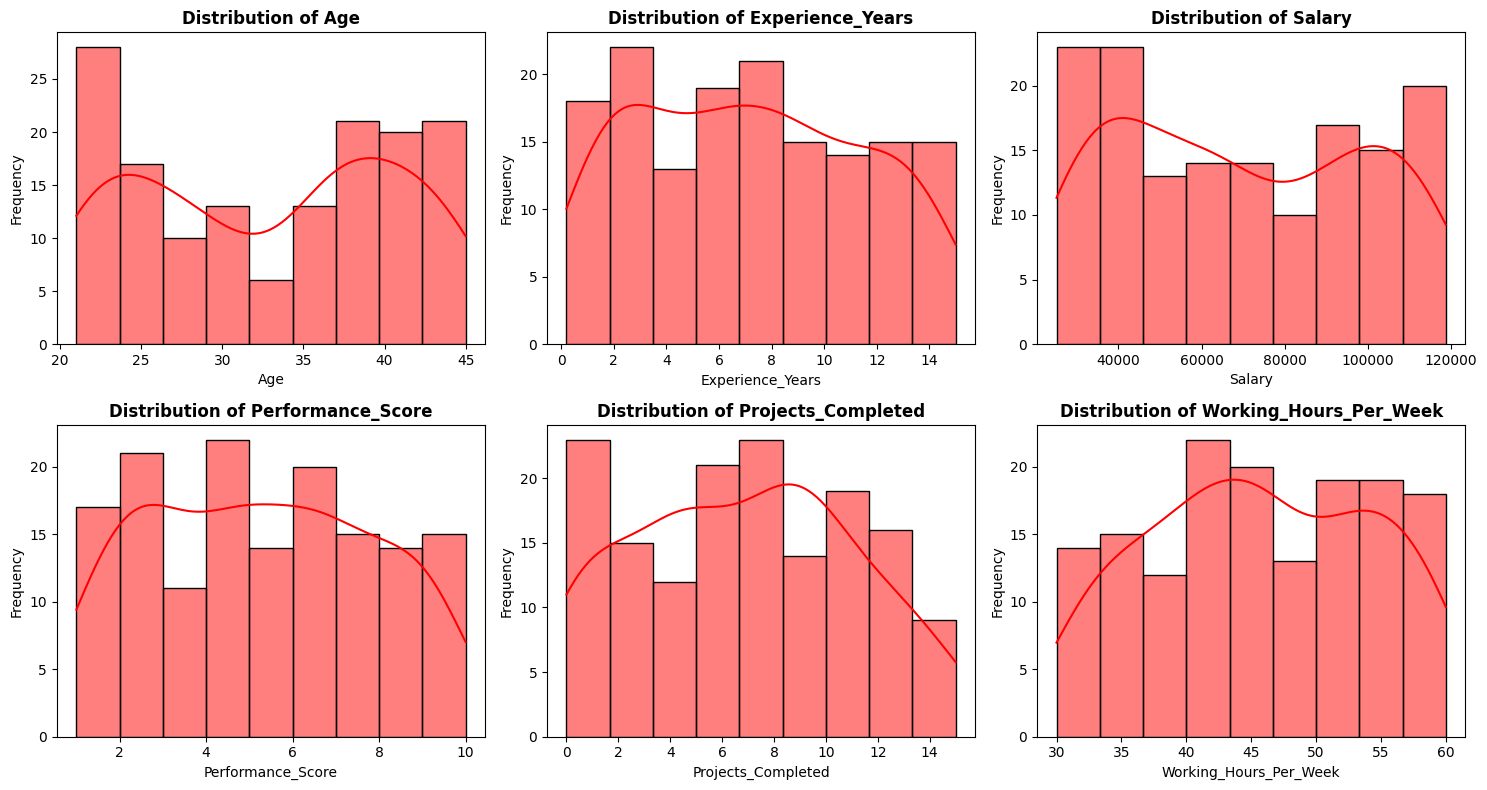

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='red', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()    



In [ ]:
df_cleaned=df

In [56]:
df_cleaned.to_csv('cleaned_employee_data.csv', index=False)

In [61]:
# Using forward slashes (recommended for clean syntax)
df_cleaned.to_csv("C:/Users/HP/Downloads/cleaned_employee_data.csv", index=False)